In [13]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# --- CONFIGURE THIS ---
input_csv_folder = r"C:\Users\chris\Desktop\University\Thesis\PipelineResults\10_patients_GM_tiles"
# ----------------------

csv_files = glob.glob(os.path.join(input_csv_folder, "pipeline_run_*.csv"))

dfs = []
for path in csv_files:
    temp_df = pd.read_csv(path)
    temp_df = temp_df.rename(columns={"scan_folder": "scan_name"})
    dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)

features = [
    "skeleton_length",
    "num_junctions",
    "num_components",
    "num_end_nodes",
    "num_start_nodes",
    "total_nodes",
    "end_to_start_ratio",
    "soma_area",
    "soma_perimeter",
    "soma_circularity",
    "cell_area",
    "cell_perimeter",
    "cell_convex_hull_area",
    "cell_convex_hull_perimeter",
    "cell_solidity",
    "cell_convexity",
    "cell_circularity",
    "cell_convex_circularity",
    "branch_area",
    "branch_perimeter",
    "sholl_min_radius",
    "sholl_peak_radius",
    "sholl_max_radius",
    "sholl_peak",
    "sholl_sum",
]

print(f"Number of cells in analysis {len(df)}")

Number of cells in analysis 156589


Remove Outliers based on cell_area

In [15]:
lower = df["cell_area"].quantile(0.002)
upper = df["cell_area"].quantile(0.998)

df = df[
    (df["cell_area"] >= lower) &
    (df["cell_area"] <= upper)
].copy()

print(f"Removed very small or very large cells")

print(f"Number of cells in analysis {len(df)}")

Removed very small or very large cells
Number of cells in analysis 155963


Remove cells that touch the image border (not fully contained in the tile)

In [16]:
# Tiles are 512x512 pixels.
# A cell whose bounding box touches any edge of the tile was clipped and
# therefore not fully visible. We remove any cell where:
#   xmin == 0  (touches left edge)
#   ymin == 0  (touches top edge)
#   xmax >= TILE_SIZE - 1  (touches right edge)
#   ymax >= TILE_SIZE - 1  (touches bottom edge)

TILE_SIZE = 512

before = len(df)

df = df[
    (df["xmin"] > 0 + 1) &
    (df["ymin"] > 0 + 1) &
    (df["xmax"] < TILE_SIZE - 1) &
    (df["ymax"] < TILE_SIZE - 1)
].copy()

print(f"Removed {before - len(df)} border-clipped cells ({before} -> {len(df)})")


# 117162

Removed 49226 border-clipped cells (155963 -> 106737)


In [17]:
from sklearn.preprocessing import StandardScaler

X = df[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Rows with complete morphology features: {len(X):,}")
print(f"Scaled feature matrix shape: {X_scaled.shape}")


Rows with complete morphology features: 106,737
Scaled feature matrix shape: (106737, 25)


## t-SNE Embedding

openTSNE runtime: 249.91s
  k=2  silhouette=0.4057
  k=3  silhouette=0.3674
  k=4  silhouette=0.3889
Best k for openTSNE: 2 (silhouette=0.4057)


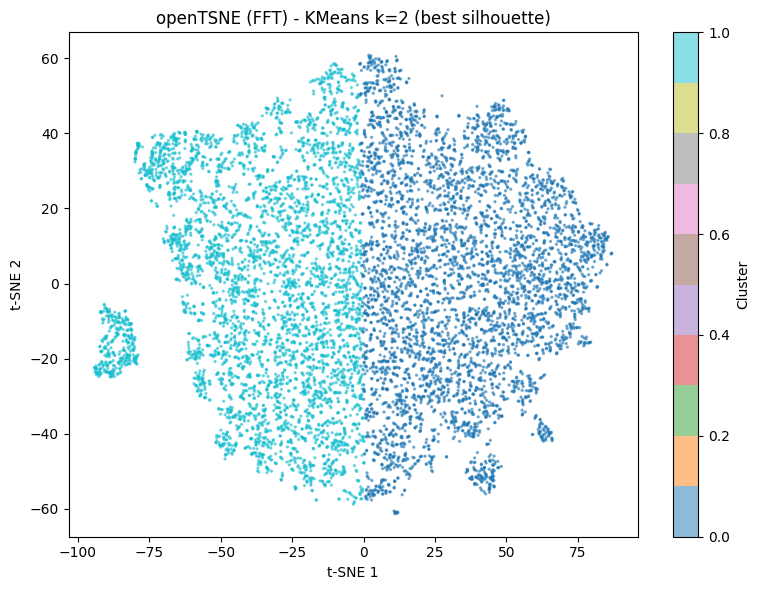

In [18]:
import time
from openTSNE import TSNE as openTSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- CONFIGURE THIS ---
TSNE_SUBSAMPLE = 10000
TSNE_K_RANGE = range(2, 5)
# ----------------------

if TSNE_SUBSAMPLE is not None and TSNE_SUBSAMPLE < len(X_scaled):
    rng = np.random.default_rng(42)
    tsne_fast_idx = rng.choice(len(X_scaled), size=TSNE_SUBSAMPLE, replace=False)
    X_tsne_fast_input = X_scaled[tsne_fast_idx]
else:
    tsne_fast_idx = np.arange(len(X_scaled))
    X_tsne_fast_input = X_scaled

t0 = time.perf_counter()
tsne_fast = openTSNE(
    n_components=2,
    perplexity=30,
    negative_gradient_method='fft',
    n_jobs=6,
    random_state=42,
)
tsne_embedding = tsne_fast.fit(X_tsne_fast_input)
X_tsne_fast = np.array(tsne_embedding)
print(f'openTSNE runtime: {time.perf_counter() - t0:.2f}s')

# Pick k with the highest silhouette score
tsne_fast_sil_scores = {}
for k in TSNE_K_RANGE:
    labels = KMeans(n_clusters=k, n_init=50, random_state=42).fit_predict(X_tsne_fast)
    tsne_fast_sil_scores[k] = silhouette_score(X_tsne_fast, labels)
    print(f'  k={k}  silhouette={tsne_fast_sil_scores[k]:.4f}')

tsne_fast_best_k = max(tsne_fast_sil_scores, key=tsne_fast_sil_scores.get)
print(f'Best k for openTSNE: {tsne_fast_best_k} (silhouette={tsne_fast_sil_scores[tsne_fast_best_k]:.4f})')

tsne_fast_kmeans = KMeans(n_clusters=tsne_fast_best_k, n_init=50, random_state=42)
tsne_fast_cluster_labels = tsne_fast_kmeans.fit_predict(X_tsne_fast)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne_fast[:, 0], X_tsne_fast[:, 1], c=tsne_fast_cluster_labels, cmap='tab10', s=2, alpha=0.5)
plt.colorbar(scatter, label='Cluster')
plt.title(f'openTSNE (FFT) - KMeans k={tsne_fast_best_k} (best silhouette)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()


## Cluster Labelling - Diverse Cell Selection


In [19]:
from pathlib import Path
import os
import shutil
import cv2
from matplotlib.patches import Patch

CLUSTER_SELECTION_OUTPUT_CSV = (
    r"C:\Users\chris\Desktop\University\Thesis"
    r"\AutomaticMicrogliaMorphologyAnalysis"
    r"\initial_pipeline\analysis"
    r"\cluster_label_cell_selection_top100.csv"
)

YOLO_CLUSTER_DIR = Path(
    r"C:\Users\chris\Desktop\University\Thesis"
    r"\AutomaticMicrogliaMorphologyAnalysis"
    r"\initial_pipeline\analysis"
    r"\yolo_cluster_label_dataset"
)

N_CLUSTER_SELECTION = 160
TILE_SIZE = 512
OTHER_CLASS_ID = 0
TARGET_CLASS_ID = 1


In [20]:
X_diverse = X_tsne_fast
print(f"Selection pool : {len(X_diverse):,} cells")
print(f"Selecting top-{N_CLUSTER_SELECTION} morphologically diverse cells...")

centroid = X_diverse.mean(axis=0, keepdims=True)
seed_d = np.linalg.norm(X_diverse - centroid, axis=1)
seed = int(np.argmax(seed_d))

selected_indices = [seed]
selection_scores = [float(seed_d[seed])]
D = np.linalg.norm(X_diverse - X_diverse[seed], axis=1).astype(np.float32)
D[seed] = -np.inf

for step in range(1, N_CLUSTER_SELECTION):
    best = int(np.argmax(D))
    best_d = float(D[best])
    if not np.isfinite(best_d):
        break
    selected_indices.append(best)
    selection_scores.append(best_d)
    d_new = np.linalg.norm(X_diverse - X_diverse[best], axis=1)
    D = np.minimum(D, d_new)
    D[best] = -np.inf

selected_np = np.array(selected_indices, dtype=int)
selected_full_positions = np.array(tsne_fast_idx)[selected_np]
selected_df_indices = np.array(X.index)[selected_full_positions]

df_selected = df.loc[selected_df_indices, [
    'global_cell_id','scan_name','image_name','xmin','ymin','xmax','ymax'
] + features].copy()

df_selected.insert(0, 'rank', range(1, len(df_selected)+1))
df_selected['diversity_score'] = selection_scores
df_selected['tsne_x'] = X_diverse[selected_np, 0]
df_selected['tsne_y'] = X_diverse[selected_np, 1]
df_selected['x_row_position'] = selected_full_positions

os.makedirs(os.path.dirname(CLUSTER_SELECTION_OUTPUT_CSV), exist_ok=True)
df_selected.to_csv(CLUSTER_SELECTION_OUTPUT_CSV, index=False)
print(f"Saved diverse-cell selection -> {CLUSTER_SELECTION_OUTPUT_CSV}")
display(df_selected.head())


Selection pool : 10,000 cells
Selecting top-160 morphologically diverse cells...
Saved diverse-cell selection -> C:\Users\chris\Desktop\University\Thesis\AutomaticMicrogliaMorphologyAnalysis\initial_pipeline\analysis\cluster_label_cell_selection_top100.csv


,rank,global_cell_id,scan_name,image_name,xmin,ymin,xmax,ymax,skeleton_length,num_junctions,...,branch_perimeter,sholl_min_radius,sholl_peak_radius,sholl_max_radius,sholl_peak,sholl_sum,diversity_score,tsne_x,tsne_y,x_row_position
73120,1,tile_x61440_y38400_gray_matter_cell_1,2017-026_Iba1_Temporal_pole_Batch_8,tile_x61440_y38400_gray_matter,21.504862,19.254723,61.95919,56.013023,0,0,...,154.852812,0,0,0,0,0,96.995402,-94.085098,-23.581824,48725
29042,2,tile_x35328_y19456_gray_matter_cell_2,2016-020_Iba1_Temporal_pole_Batch_8,tile_x35328_y19456_gray_matter,21.872040,30.620636,185.96805,293.181700,646,17,...,1196.572717,33,62,243,17,646,183.762985,86.926498,8.098445,19874
59716,3,tile_x67072_y7680_gray_matter_cell_0,2017-014_Iba1_Temporal_pole_Batch_6,tile_x67072_y7680_gray_matter,407.937260,347.055660,490.75060,508.904800,103,1,...,280.793937,27,45,65,10,103,111.740791,-14.499291,54.989955,39743
5123,4,tile_x36352_y15360_gray_matter_cell_0,2014-048_Iba1_Temporal_pole_Batch_8,tile_x36352_y15360_gray_matter,390.704000,340.756900,485.78354,436.358100,154,4,...,293.178713,11,27,81,5,154,103.826434,5.015827,-55.702576,3722
122836,5,tile_x14848_y53248_gray_matter_cell_0,2017-160_Iba1_Temporal_pole_Batch_6,tile_x14848_y53248_gray_matter,125.077810,34.270977,289.61005,157.854230,205,4,...,537.629505,14,46,73,7,205,62.875748,23.896962,4.271271,82488


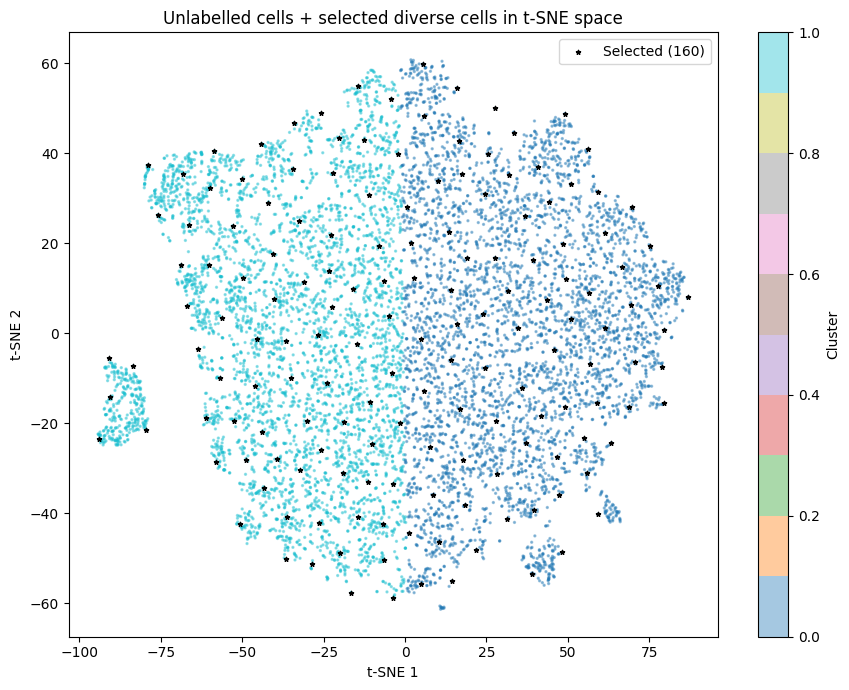

In [21]:
sel_coords = X_diverse[selected_np]
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(X_tsne_fast[:, 0], X_tsne_fast[:, 1], c=tsne_fast_cluster_labels, cmap='tab10', s=2, alpha=0.4, zorder=1)
plt.colorbar(sc, ax=ax, label='Cluster')
ax.scatter(sel_coords[:, 0], sel_coords[:, 1], marker='*', color='black', s=10, zorder=2, label=f'Selected ({len(sel_coords):,})')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('Unlabelled cells + selected diverse cells in t-SNE space')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


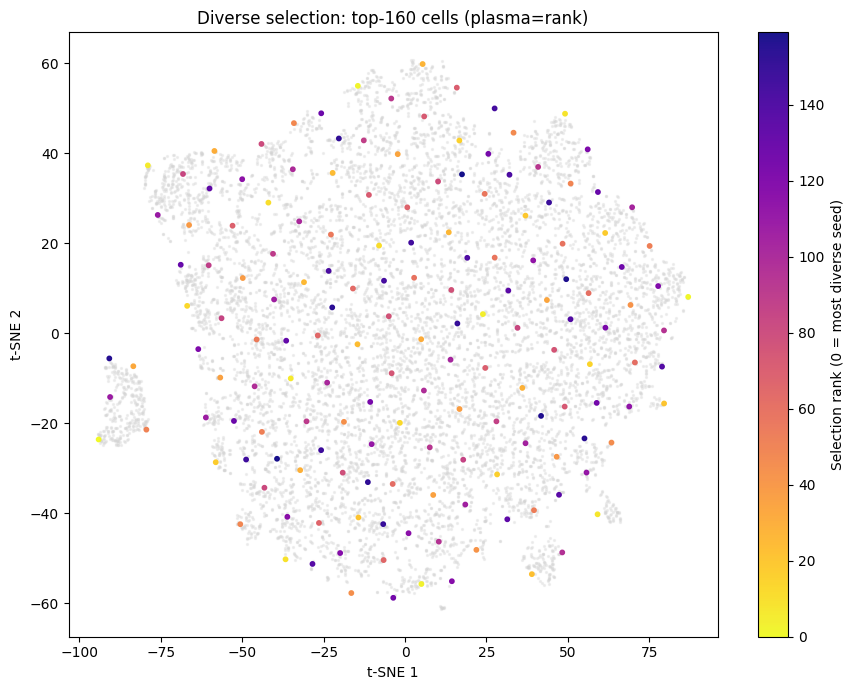

In [22]:
ranks = np.arange(len(selected_np))
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_tsne_fast[:, 0], X_tsne_fast[:, 1], c='lightgrey', s=2, alpha=0.3, zorder=1, rasterized=True)
sc2 = ax.scatter(sel_coords[:, 0], sel_coords[:, 1], c=ranks, cmap='plasma_r', s=10, zorder=2, alpha=0.95)
plt.colorbar(sc2, ax=ax, label='Selection rank (0 = most diverse seed)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(f'Diverse selection: top-{len(selected_np)} cells (plasma=rank)')
plt.tight_layout()
plt.show()


## Export Ultralytics YOLO Dataset for Cluster Labelling

All cells in each selected image are exported. Selected target cells are class `microglia_to_annotate_cluster` and all others are `other_microglia`.


In [23]:
scan_data_root = r"C:\Users\chris\Desktop\University\Thesis\ScanData\All_scans_tiled"
selected_keys = set(zip(df_selected['scan_name'], df_selected['global_cell_id']))
selected_image_names = set(df_selected['image_name'].unique())

# Keep only cells that should be annotated (selected targets)
key_series = list(zip(df['scan_name'], df['global_cell_id']))
df_export = df[pd.Series(key_series, index=df.index).isin(selected_keys)].copy()

df_export['class_id'] = 0  # single class for annotation targets only
df_export['x_center'] = ((df_export['xmin'] + df_export['xmax']) / 2.0) / TILE_SIZE
df_export['y_center'] = ((df_export['ymin'] + df_export['ymax']) / 2.0) / TILE_SIZE
df_export['box_w'] = (df_export['xmax'] - df_export['xmin']) / TILE_SIZE
df_export['box_h'] = (df_export['ymax'] - df_export['ymin']) / TILE_SIZE

img_out_dir = YOLO_CLUSTER_DIR / 'images' / 'train'
lbl_out_dir = YOLO_CLUSTER_DIR / 'labels' / 'train'
img_out_dir.mkdir(parents=True, exist_ok=True)
lbl_out_dir.mkdir(parents=True, exist_ok=True)

train_entries = []
for image_name, grp in df_export.groupby('image_name'):
    scan_name = grp['scan_name'].iloc[0]
    src_img = Path(scan_data_root) / scan_name / (image_name + '.jpg')
    if not src_img.exists():
        continue

    dst_img = img_out_dir / (image_name + '.jpg')
    if not dst_img.exists():
        shutil.copy2(src_img, dst_img)

    train_entries.append(f"data/images/train/{image_name}.jpg")

    with open(lbl_out_dir / (image_name + '.txt'), 'w', encoding='utf-8') as f:
        for _, row in grp.iterrows():
            f.write(
                f"{int(row['class_id'])} {row['x_center']:.6f} {row['y_center']:.6f} "
                f"{row['box_w']:.6f} {row['box_h']:.6f}\n"
            )

train_txt_path = YOLO_CLUSTER_DIR / 'train.txt'
train_lines = sorted(set(train_entries))
train_txt_path.write_text('\n'.join(train_lines) + ('\n' if train_lines else ''), encoding='utf-8')

(YOLO_CLUSTER_DIR / 'data.yaml').write_text(
    "path: .\n"
    "train: train.txt\n"
    "val: train.txt\n\n"
    "names:\n"
    "  0: microglia_to_annotate_cluster\n",
    encoding='utf-8'
)

print(f"Export target cells only: {len(df_export):,} annotations across {df_export['image_name'].nunique():,} images")
print(f"Unique selected (scan_name, global_cell_id) keys: {len(selected_keys):,}")
print(f"Wrote train.txt  -> {train_txt_path}")
print(f"Dataset ready at: {YOLO_CLUSTER_DIR.resolve()}")


Export target cells only: 160 annotations across 158 images
Unique selected (scan_name, global_cell_id) keys: 160
Wrote train.txt  -> C:\Users\chris\Desktop\University\Thesis\AutomaticMicrogliaMorphologyAnalysis\initial_pipeline\analysis\yolo_cluster_label_dataset\train.txt
Dataset ready at: C:\Users\chris\Desktop\University\Thesis\AutomaticMicrogliaMorphologyAnalysis\initial_pipeline\analysis\yolo_cluster_label_dataset
